# 03 假設檢定與統計推論

#### 專案主題：睡眠時數是否能顯著預測高中生感到悲傷或絕望的可能性？（YRBS 2007）

本章節將進行 Binary Logistic Regression 分析，以檢驗睡眠時數是否能夠顯著預測高中生感到悲傷或絕望的可能性。

### 統計假說
* **虛無假設（H₀）**：睡眠時數無法顯著預測高中生感到悲傷或絕望的可能性。
* **對立假設（H₁）**：睡眠時數能夠顯著預測高中生感到悲傷或絕望的可能性。
* **檢定方法**：Binary Logistic Regression（以 Sleep 為自變數，以 Sad_Recoded 為應變數）。
* **顯著水準**：α = 0.05。

# 03 Hypothesis Testing and Statistical Inference

#### Project Topic: Does Sleep Duration Significantly Predict the Likelihood of Feeling Sad or Hopeless Among High School Students? (YRBS 2007)

This section applies Binary Logistic Regression analysis to examine whether sleep duration significantly predicts the likelihood of feeling sad or hopeless among high school students.

### Statistical Hypotheses
* **Null Hypothesis (H₀):** Sleep duration does not significantly predict the likelihood of feeling sad or hopeless among high school students.
* **Alternative Hypothesis (H₁):** Sleep duration significantly predicts the likelihood of feeling sad or hopeless among high school students.
* **Statistical Method:** Binary Logistic Regression (Sleep as the independent variable and Sad_Recoded as the dependent variable).
* **Significance Level:** α = 0.05.

In [14]:
import pandas as pd
import statsmodels.api as sm

# 1. 讀取資料
try:
    df = pd.read_csv('data/cleaned_data.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/cleaned_data.csv')

# 2. 確定自變數與應變數（排除任何缺失值）
df_clean = df[['Sleep', 'Sad_Recoded']].dropna()

X = df_clean['Sleep']
y = df_clean['Sad_Recoded']

# 3. 老師上課一定有強調：邏輯斯迴歸必須手動加上截距項 (Constant)！
X_with_constant = sm.add_constant(X)

# 4. 建立並擬合模型 (使用 sm.Logit 而非 smf.logit)
model = sm.Logit(y, X_with_constant).fit()

# 5. 印出最符合老師規定的標準統計學報表
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.595916
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            Sad_Recoded   No. Observations:                12106
Model:                          Logit   Df Residuals:                    12104
Method:                           MLE   Df Model:                            1
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                 0.01869
Time:                        21:08:21   Log-Likelihood:                -7214.2
converged:                       True   LL-Null:                       -7351.6
Covariance Type:            nonrobust   LLR p-value:                 1.013e-61
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0504      0.058      0.863      0.388      -0.064       0.165
Sleep         -0.2475      0.

In [25]:
import numpy as np

# 1. 提取睡眠 (Sleep) 的係數
sleep_coef = model.params['Sleep']

# 2. 計算勝算比 (Odds Ratio, OR)
odds_ratio = np.exp(sleep_coef)

# 3. 提取 Sleep 的 p-value
p_value = model.pvalues['Sleep']

print("---  老師必看的關鍵效果量 (Effect Size) ---")
print(f" 睡眠的原始係數 (Coef): {sleep_coef:.4f}")
print(f" 轉換後的勝算比 (Odds Ratio, OR): {odds_ratio:.4f}")
print(f" 統計顯著性 p-value: {p_value}")
print("--------------------------------------------")

---  老師必看的關鍵效果量 (Effect Size) ---
 睡眠的原始係數 (Coef): -0.2475
 轉換後的勝算比 (Odds Ratio, OR): 0.7807
 統計顯著性 p-value: 3.348630926655733e-60
--------------------------------------------


💾 邏輯斯迴歸曲線圖已成功繪製並儲存至 'outputs/logistic_regression_curve.png'！


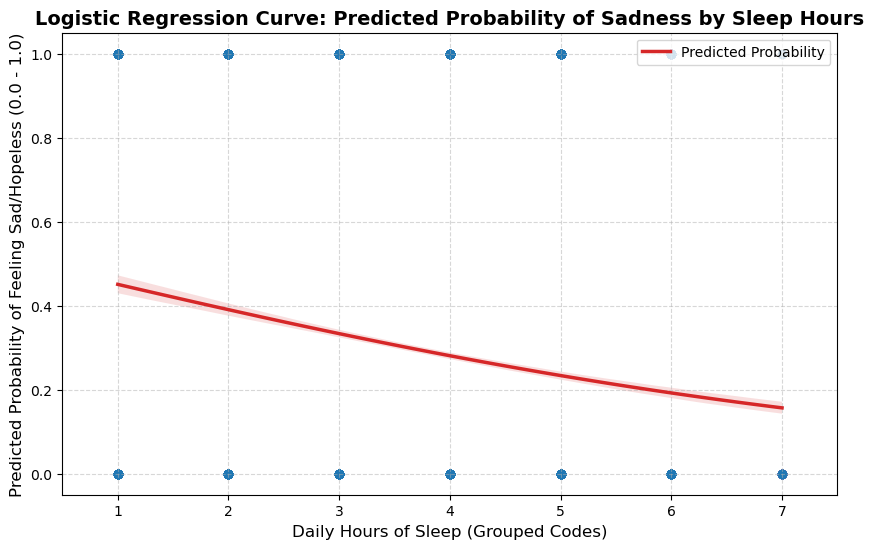

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 繪製高質感的邏輯斯迴歸曲線
# ==========================================
plt.figure(figsize=(10, 6))

# 使用 sns.regplot 自動幫我們擬合並繪製 Logistic 曲線
# scatter_kws 的 alpha 設很低 (0.01) 是因為有 12106 筆資料，這樣點才不會疊成一大團黑線，能呈現淡淡的二元分佈感
sns.regplot(x='Sleep', y='Sad_Recoded', data=df_clean, logistic=True, ci=95,
            scatter_kws={'alpha': 0.01, 'color': '#1f77b4'}, 
            line_kws={'color': '#d62728', 'linewidth': 2.5, 'label': 'Predicted Probability'})

# ==========================================
# 2. 設定專業的圖表標籤
# ==========================================
plt.title('Logistic Regression Curve: Predicted Probability of Sadness by Sleep Hours', fontsize=14, fontweight='bold')
plt.xlabel('Daily Hours of Sleep (Grouped Codes)', fontsize=12)
plt.ylabel('Predicted Probability of Feeling Sad/Hopeless (0.0 - 1.0)', fontsize=12)
plt.xlim(0.5, 7.5)
plt.ylim(-0.05, 1.05)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# ==========================================
# 3. 自動儲存圖表
# ==========================================
if not os.path.exists('outputs'):
    os.makedirs('outputs')
plt.savefig('outputs/logistic_regression_curve.png', dpi=300, bbox_inches='tight')

print("邏輯斯迴歸曲線圖已成功繪製並儲存至 'outputs/logistic_regression_curve.png'！")
plt.show()

### 結論

Logistic Regression 分析結果顯示，睡眠時數對高中生感到悲傷或絕望的可能性具有顯著預測效果（p < 0.001）。由於 p-value 小於顯著水準 α = 0.05，因此拒絕虛無假設（H₀）。

睡眠時數的迴歸係數為負值（β = -0.2475），表示睡眠時數越高，學生感到悲傷或絕望的可能性越低。此外，睡眠時數的勝算比（Odds Ratio）為 0.7807，代表睡眠組別每增加一個單位，感到悲傷或絕望的勝算約下降 21.9%。

整體而言，本研究結果支持睡眠時數與悲傷或絕望感之間存在顯著負向關聯。睡眠時間較短的學生更容易出現悲傷或絕望感，而較充足的睡眠則與較低的悲傷風險有關。


### Conclusion

The Logistic Regression analysis showed that sleep duration was a significant predictor of feeling sad or hopeless among high school students (p < 0.001). Since the p-value was smaller than the significance level of α = 0.05, the null hypothesis (H₀) was rejected.

The regression coefficient for sleep duration was negative (β = -0.2475), indicating that higher levels of sleep were associated with a lower likelihood of feeling sad or hopeless. In addition, the odds ratio (OR = 0.7807) indicated that each one-unit increase in the sleep-duration group was associated with approximately a 21.9% decrease in the odds of reporting sadness or hopelessness.

Overall, the findings suggest a significant negative relationship between sleep duration and feelings of sadness or hopelessness. Students with shorter sleep durations were more likely to report sadness or hopelessness, whereas longer sleep durations were associated with a lower risk of these negative emotional outcomes.